# Problem-Statement Labeling (v2) — Original vs Labeled

Classical labeling that follows the problem statement, applied **per cell** so it also finds the actin between neighbouring cells.

| Problem statement | What happens here |
|---|---|
| Global Cell Segmentation | Gaussian smoothing → Otsu (with hysteresis) → solid binary mask of the cells |
| *(extension)* individual cells | Marker-controlled watershed splits the mask into cells; borders follow the bright junctions |
| Boundary Band Definition | For **every cell**: erode by a pixel radius, subtract → ring along its edge |
| HoG based labelling | HOG-style orientation histograms → oriented-edge-strength map |
| Targeted Intensity Thresholding | Higher threshold on local contrast, **only inside the bands**, gated by HOG |
| Binary Mask Extraction | Cleaned final binary mask |

**Why per cell?** One footprint for the whole image has only one outer edge, so in a dense monolayer the band never reaches the cell–cell junctions where most actin sits. Giving each cell its own band puts the junctions inside bands.

Needs only `label_statement.py` next to this notebook (no `config.py`, no TensorFlow).

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import replace

from label_statement import (Params, label_path, list_images, make_overlay,
                             cell_outline_overlay, build_panel_figure)

# ---- EDIT THIS: folder containing your .tif images -------------------------
INPUT_DIR = "data/raw"
# ----------------------------------------------------------------------------

P = Params()          # defaults; every knob is documented in label_statement.Params
image_paths = list_images(INPUT_DIR)
print(f"Found {len(image_paths)} image(s) in '{INPUT_DIR}'")
for p in image_paths:
    print("  ", os.path.basename(p))

Found 6 image(s) in 'data/raw'
   1.tif
   2.tif
   3.tif
   4.tif
   5.tif
   6.tif


## 1. Original vs Labeled — every image
Left: original · Middle: final binary mask · Right: mask overlaid in green.

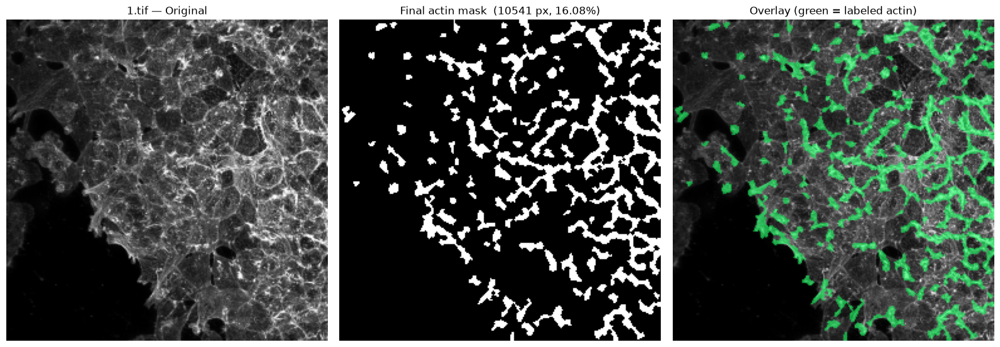

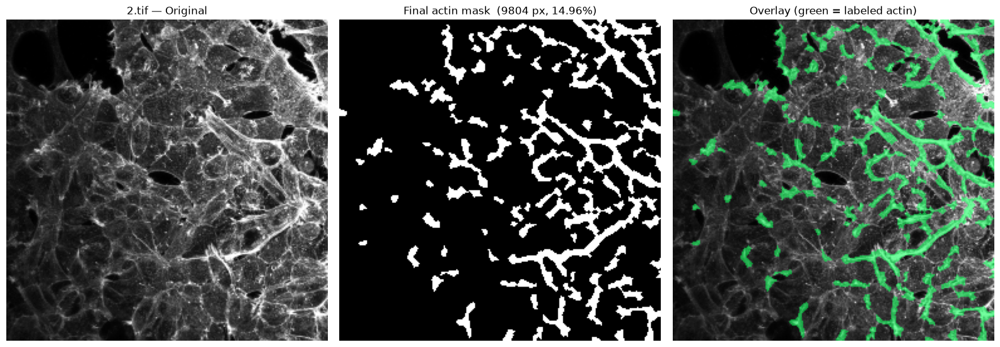

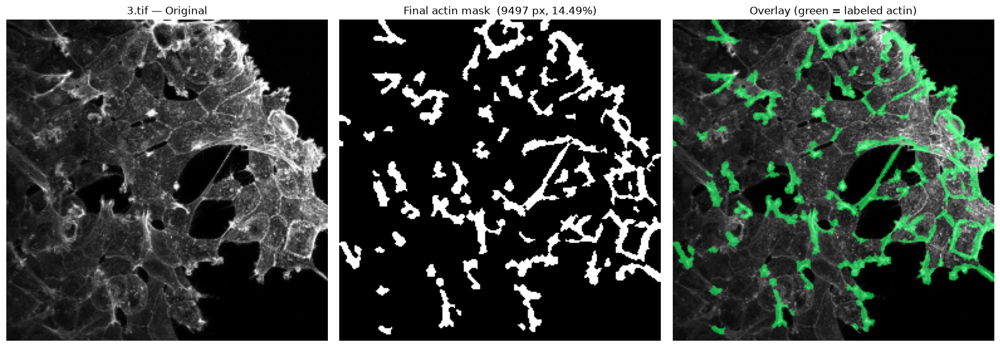

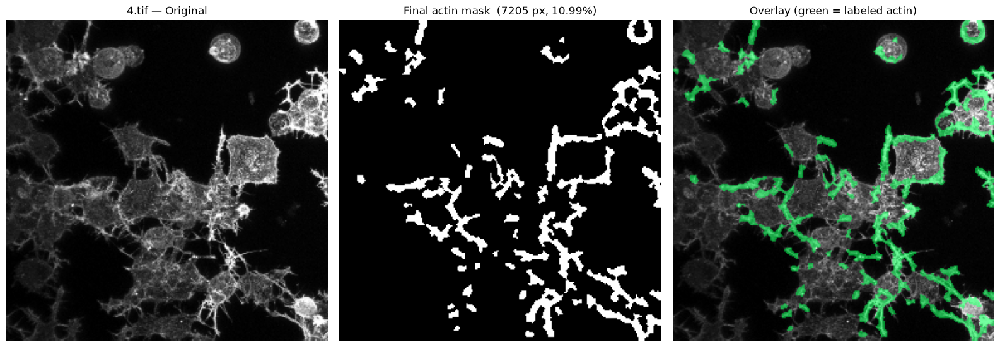

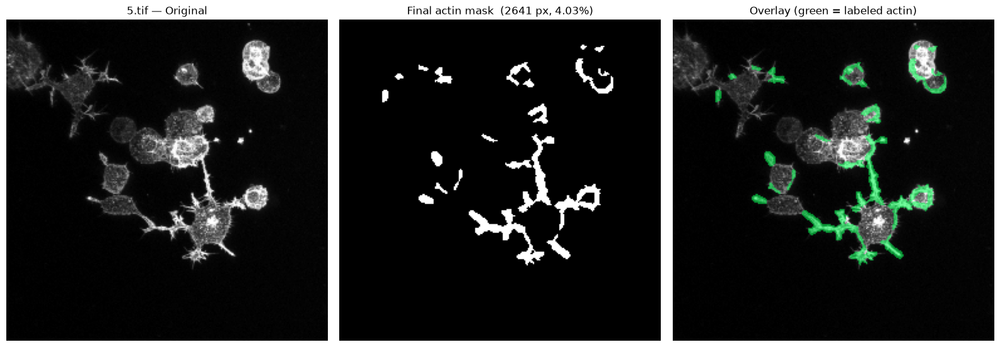

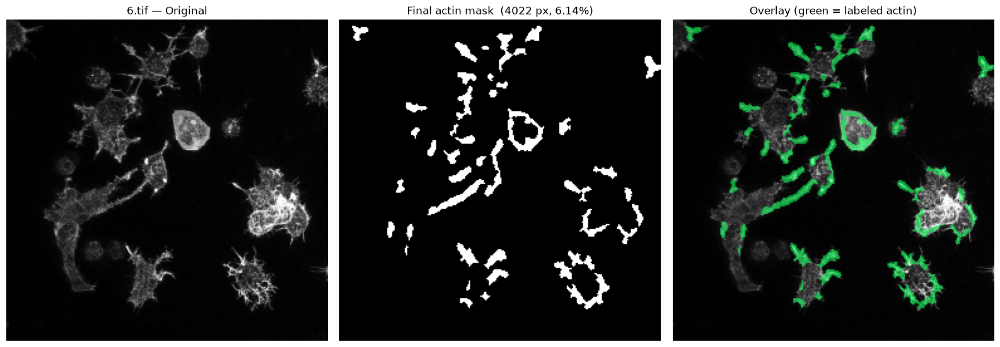

In [4]:
results = {}
for path in image_paths:
    name = os.path.basename(path)
    out = label_path(path, P)
    results[name] = out

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.4))
    axes[0].imshow(out["image"], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"{name} — Original", fontsize=12)
    axes[1].imshow(out["mask"], cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Final actin mask  ({out['actin_pixels']} px, {out['actin_percent']:.2f}%)", fontsize=12)
    axes[2].imshow(make_overlay(out["image"], out["mask"]))
    axes[2].set_title("Overlay (green = labeled actin)", fontsize=12)
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 2. Every intermediate stage
Use these for the *labeled data / algorithm* slide — they show each step of the problem statement.

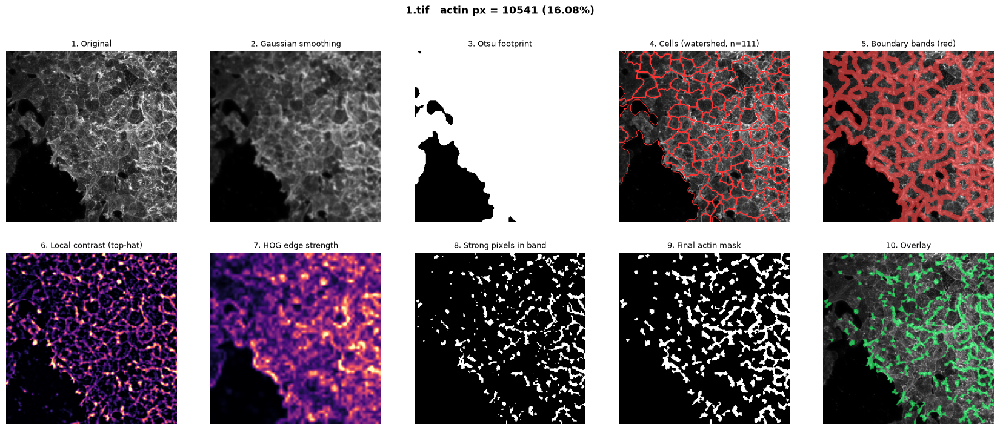

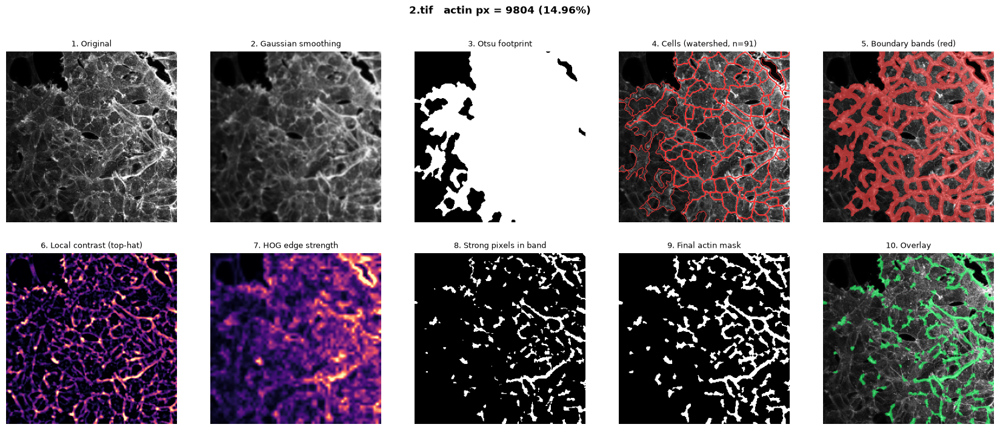

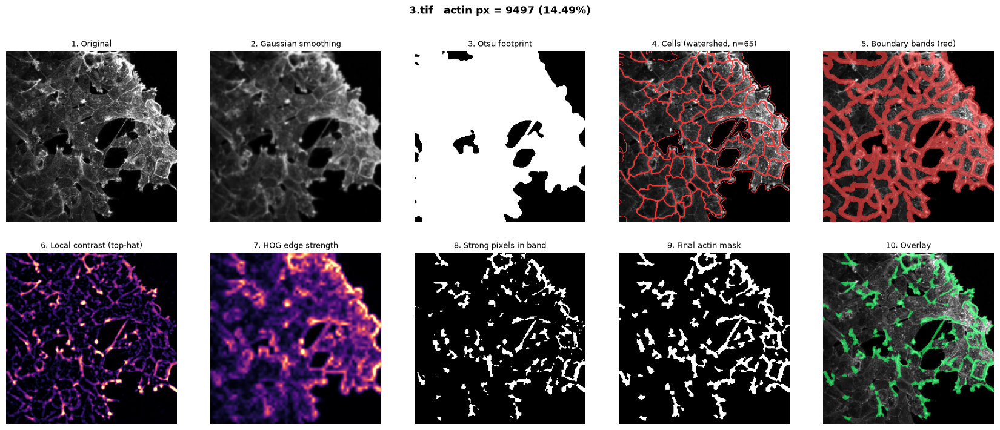

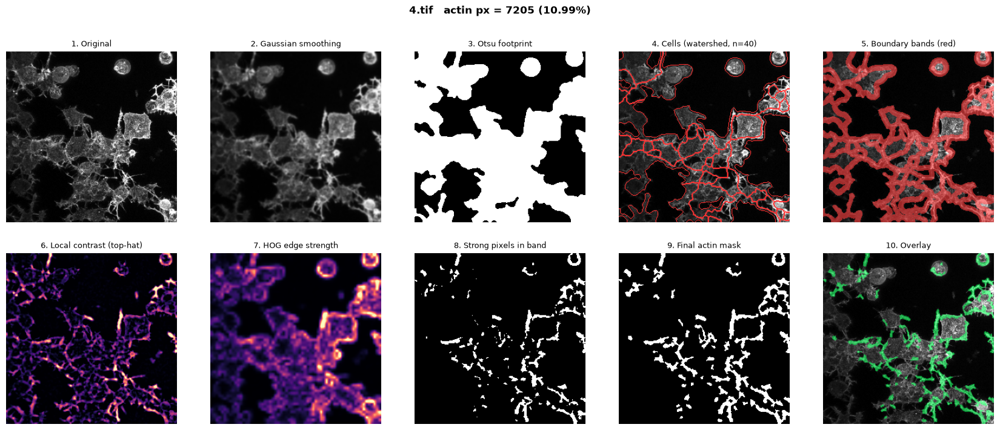

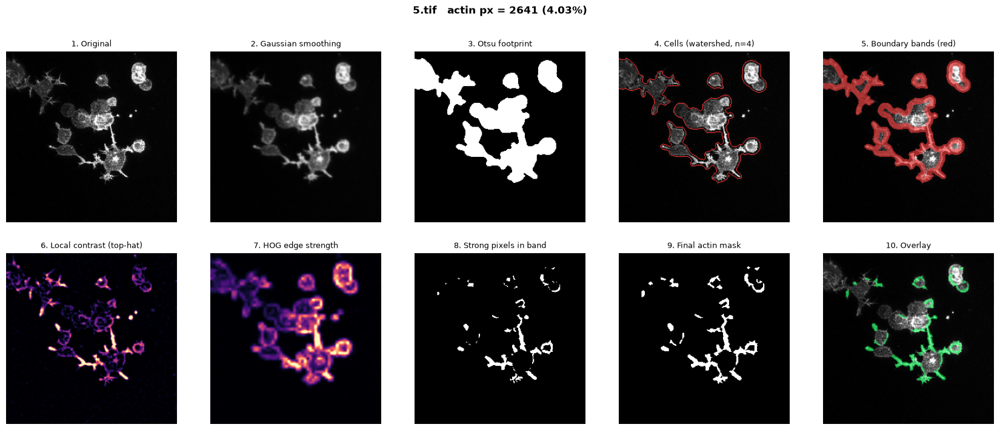

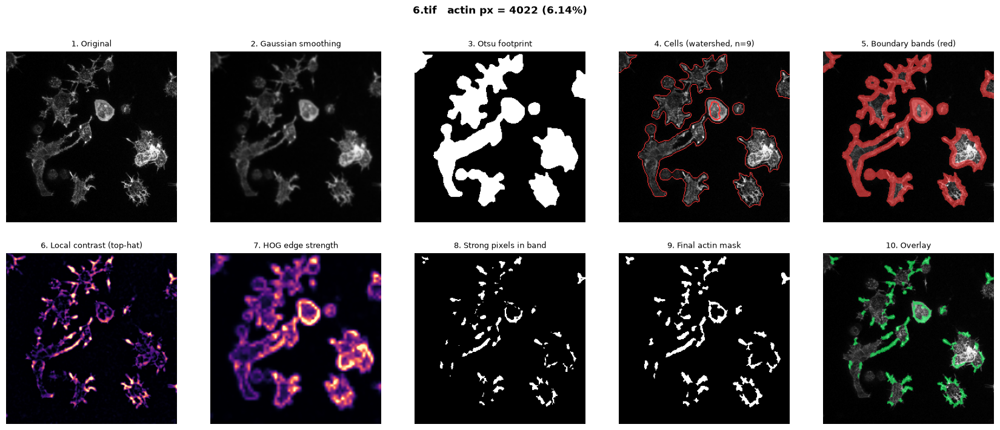

In [5]:
for name, out in results.items():
    build_panel_figure(out, title=name)
    plt.show()

## 3. Statistics table

In [6]:
rows = []
for name, out in results.items():
    rows.append({
        "image": name,
        "footprint_%": round(out["footprint"].mean() * 100, 1),
        "cells_found": out["n_cells"],
        "band_%": round(out["band"].mean() * 100, 1),
        "actin_px": out["actin_pixels"],
        "actin_%": round(out["actin_percent"], 2),
    })
print(pd.DataFrame(rows).to_string(index=False))

image  footprint_%  cells_found  band_%  actin_px  actin_%
1.tif         82.8          111    51.6     10541    16.08
2.tif         76.9           91    49.9      9804    14.96
3.tif         78.7           65    48.4      9497    14.49
4.tif         54.2           40    39.4      7205    10.99
5.tif         19.5            4    14.7      2641     4.03
6.tif         26.9            9    21.2      4022     6.14


## 4. Tuning — compare settings on one image
Change `IMAGE_NAME`, compare the overlays, and copy the best values into `Params` in `label_statement.py`.
Look for: lines that follow real bright actin (precision) **and** few bright junctions left unlabeled (recall).

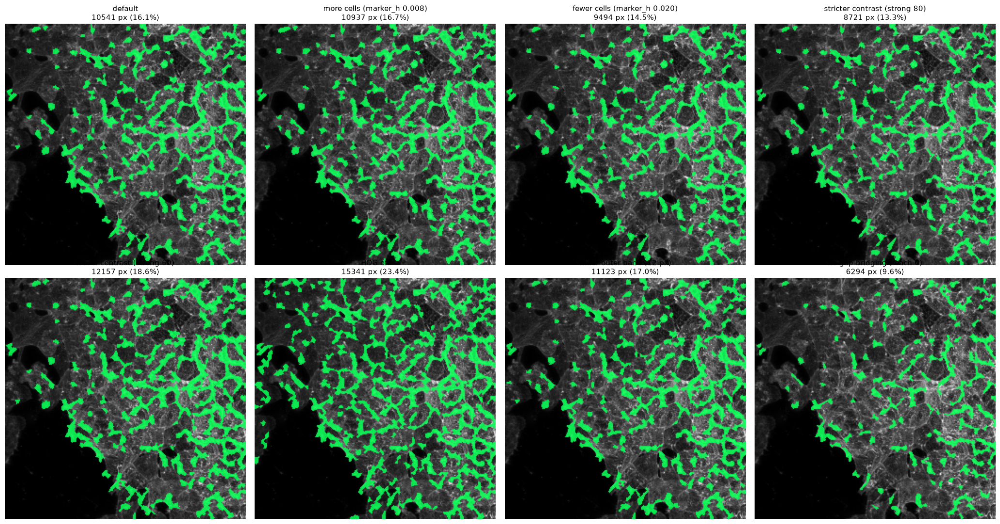

In [7]:
IMAGE_NAME = os.path.basename(image_paths[0])      # <- change to any file name listed above
path = os.path.join(INPUT_DIR, IMAGE_NAME)

variants = {
    "default":                          P,
    "more cells (marker_h 0.008)":      replace(P, cell_marker_h=0.008),
    "fewer cells (marker_h 0.020)":     replace(P, cell_marker_h=0.020),
    "stricter contrast (strong 80)":    replace(P, strong_contrast_percentile=80, weak_contrast_percentile=65),
    "looser contrast (strong 60)":      replace(P, strong_contrast_percentile=60, weak_contrast_percentile=45),
    "HOG off":                          replace(P, use_hog=False),
    "wider outer band (12 px)":         replace(P, band_radius_outer_px=12),
    "no gap bridging (reach 0)":        replace(P, reach_px=0),
}

n = len(variants)
cols = 4
rows_ = (n + cols - 1) // cols
fig, axes = plt.subplots(rows_, cols, figsize=(5.2 * cols, 5.4 * rows_))
for ax, (label, params) in zip(axes.ravel(), variants.items()):
    o = label_path(path, params)
    ax.imshow(make_overlay(o["image"], o["mask"], alpha=0.85))
    ax.set_title(f"{label}\n{o['actin_pixels']} px ({o['actin_percent']:.1f}%)", fontsize=11)
    ax.axis("off")
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. What to change if the mask looks wrong

| Symptom | Parameter (`Params`) | Change |
|---|---|---|
| Cells are merged / junctions not found inside a cluster | `cell_marker_h` | lower (0.008) |
| One real cell is cut into several pieces | `cell_marker_h` | raise (0.02) |
| Footprint bleeds into dark background | `footprint_low_frac` | raise toward 1.0 |
| Dim cells missing from the footprint | `footprint_low_frac` | lower (0.6–0.7) |
| Outer rim of isolated cells not labeled | `band_radius_outer_px` | raise (10–12) |
| Junction labels too thick | `band_radius_inner_px` | lower (2) |
| Too much non-actin labeled | `strong_contrast_percentile` / `strong_hog_percentile` | raise |
| Real actin still missing | `strong_contrast_percentile` / `weak_contrast_percentile` | lower |
| Junctions broken into pieces | `reach_px` | raise (4–5) |
| Speckle in mask | `final_min_object_px` | raise (20+) |

## 6. Honest limitations (say these yourself in the report)
* There is **no hand-drawn ground truth**, so quality was judged visually plus against the Frangi ridge map as a *proxy* (not truth).
* Very faint / out-of-focus actin (e.g. the dim left edge of some images) is deliberately not labeled.
* Thin isolated filopodia that lie outside the cell footprint can still be missed.
* On an image with no real actin the pipeline still labels the brightest structures (it has no "nothing here" detector).